# Customer Churn Prediction

# 6. Decision Tree Classifier

## Business Objective

The objective of this phase is to build a Decision Tree Classifier and compare its performance with the Logistic Regression model.

Decision Trees are capable of learning complex, non-linear relationships and provide an interpretable set of decision rules for predicting customer churn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a classification model using common performance metrics.
    """

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("=" * 50)
    print(f"Model : {model.__class__.__name__}")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model.__class__.__name__}")

    plt.show()

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title(f"ROC Curve - {model.__class__.__name__}")
    plt.show()

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    }

In [3]:
X = pd.read_csv("../data/processed/X_scaled.csv")
y = pd.read_csv("../data/processed/y.csv").squeeze()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [6]:
decision_tree.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Model : DecisionTreeClassifier
Accuracy : 0.7193
Precision: 0.4717
Recall   : 0.4679
F1 Score : 0.4698
AUC Score: 0.6388

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.47      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



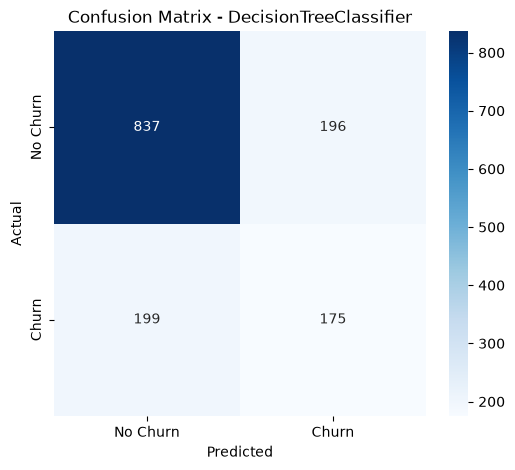

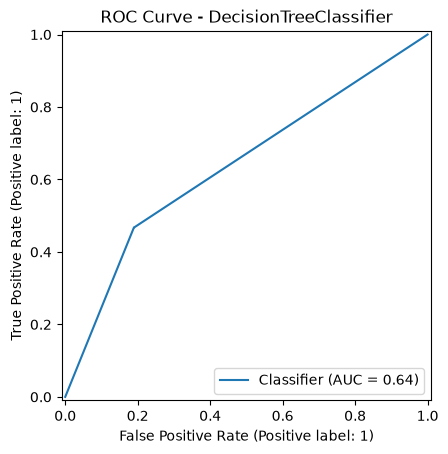

{'Model': 'DecisionTreeClassifier',
 'Accuracy': 0.7192608386638237,
 'Precision': 0.4716981132075472,
 'Recall': 0.4679144385026738,
 'F1 Score': 0.4697986577181208,
 'AUC': 0.6388303627356072}

In [7]:
results_dt = evaluate_model(
    decision_tree,
    X_test,
    y_test
)

results_dt

In [8]:
results_df = pd.DataFrame([results_dt])

results_df.to_csv(
    "../results/decision_tree_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


### Business Interpretation

The Decision Tree Classifier achieved lower performance than the Logistic Regression model across all evaluation metrics.

This suggests that the default Decision Tree overfit the training data and did not generalize well to unseen customers.

Further tuning of Decision Tree hyperparameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` may improve performance.

# 6.6 Hyperparameter Tuning

## Why tune a Decision Tree?

By default, a Decision Tree continues splitting until it perfectly fits the training data.

This often leads to **overfitting**, where the model memorizes the training data instead of learning general patterns.

Hyperparameter tuning controls the complexity of the tree, helping it generalize better to unseen customers.

We will tune:

- max_depth
- min_samples_split
- min_samples_leaf

In [9]:
# Tuned Decision Tree

decision_tree_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

In [10]:
decision_tree_tuned.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

Model : DecisionTreeClassifier
Accuracy : 0.7783
Precision: 0.5807
Recall   : 0.5963
F1 Score : 0.5884
AUC Score: 0.8197

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



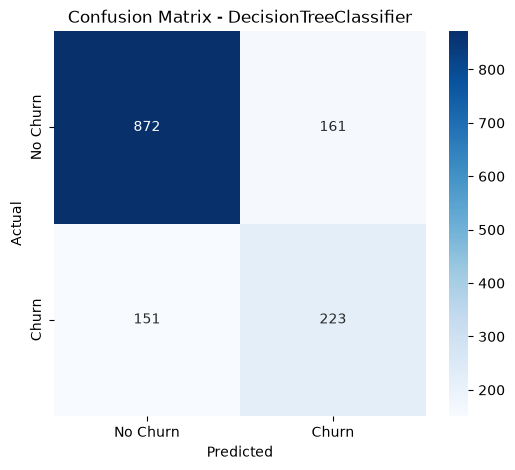

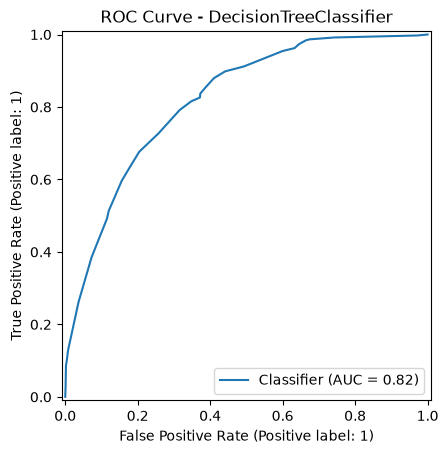

{'Model': 'DecisionTreeClassifier',
 'Accuracy': 0.7782515991471215,
 'Precision': 0.5807291666666666,
 'Recall': 0.5962566844919787,
 'F1 Score': 0.5883905013192612,
 'AUC': 0.8197089625254307}

In [11]:
results_dt_tuned = evaluate_model(
    decision_tree_tuned,
    X_test,
    y_test
)

results_dt_tuned

In [12]:
results_df = pd.DataFrame([results_dt_tuned])

results_df.to_csv(
    "../results/tuned_decision_tree_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


# 6.7 Model Comparison

We compare the default Decision Tree against the tuned Decision Tree to determine whether limiting the tree complexity improves predictive performance.

In [11]:
comparison = pd.DataFrame({
    "Default Tree": results_dt,
    "Tuned Tree": results_dt_tuned
})

comparison

,Default Tree,Tuned Tree
Model,DecisionTreeClassifier,DecisionTreeClassifier
Accuracy,0.719261,0.778252
Precision,0.471698,0.580729
Recall,0.467914,0.596257
F1 Score,0.469799,0.588391
AUC,0.63883,0.819709


## Business Interpretation

The tuned Decision Tree significantly outperformed the default Decision Tree across all evaluation metrics.

Restricting the tree depth and increasing the minimum number of samples required for splitting reduced overfitting and improved generalization.

Although Logistic Regression still achieved the highest overall Accuracy and F1 Score, the tuned Decision Tree achieved the highest Recall, making it a strong candidate when identifying potential churn customers is the primary business objective.